# 01 - Data Preparation

Notebook ini digunakan untuk mempersiapkan dataset sebelum training.
Urutan: deteksi environment -> install library -> setup folder -> load dataset NIH -> load MP-IDB -> preprocessing -> split -> verifikasi.

## Setup Environment

In [1]:
# cek apakah running di colab atau jupyter lokal
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    # sesuaikan dengan path folder project di google drive
    PROJECT_ROOT = '/content/drive/MyDrive/malaria-detection'
    os.makedirs(PROJECT_ROOT, exist_ok=True)
    os.chdir(PROJECT_ROOT)
else:
    import os
    # kalau lokal, asumsikan notebook dijalankan dari folder notebooks/
    PROJECT_ROOT = os.path.abspath('..')
    os.chdir(PROJECT_ROOT)

print('working directory:', os.getcwd())

working directory: d:\malaria-detection


In [2]:
# install semua yang dibutuhkan
!pip install -q kaggle roboflow ultralytics opencv-python-headless albumentations matplotlib scikit-learn tqdm Pillow numpy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import shutil
import random
from pathlib import Path
from tqdm import tqdm

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [4]:
# definisikan semua path yang dipakai di notebook ini
PATHS = {
    'raw_nih'   : os.path.join('datasets', 'raw', 'NIH'),
    'raw_mpidb' : os.path.join('datasets', 'raw', 'MP-IDB'),
    'processed' : os.path.join('datasets', 'processed'),
    'img_train' : os.path.join('datasets', 'processed', 'images', 'train'),
    'img_val'   : os.path.join('datasets', 'processed', 'images', 'val'),
    'img_test'  : os.path.join('datasets', 'processed', 'images', 'test'),
    'lbl_train' : os.path.join('datasets', 'processed', 'labels', 'train'),
    'lbl_val'   : os.path.join('datasets', 'processed', 'labels', 'val'),
    'lbl_test'  : os.path.join('datasets', 'processed', 'labels', 'test'),
    'figures'   : os.path.join('results', 'figures'),
}

for path in PATHS.values():
    os.makedirs(path, exist_ok=True)

print('semua folder sudah dibuat')

semua folder sudah dibuat


## Load Dataset - NIH (Kaggle)

In [5]:
# setup kaggle.json
# file kaggle.json bisa didownload dari kaggle.com -> Settings -> API -> Create New Token

if IN_COLAB:
    from google.colab import files
    print('upload kaggle.json')
    files.upload()
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
else:
    kaggle_path = os.path.expanduser('~/.kaggle/kaggle.json')
    if os.path.exists(kaggle_path):
        print('kaggle.json ditemukan:', kaggle_path)
    else:
        print('kaggle.json tidak ditemukan, letakkan di:', kaggle_path)

kaggle.json ditemukan: C:\Users\ASUS/.kaggle/kaggle.json


In [6]:
# download dataset NIH malaria dari kaggle
# hasil download otomatis masuk ke datasets/raw/NIH/
DOWNLOAD_DIR = os.path.join(PROJECT_ROOT, PATHS['raw_nih'])
os.makedirs(DOWNLOAD_DIR, exist_ok=True)

!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria \
    -p {DOWNLOAD_DIR} --unzip

print('dataset tersimpan di:', DOWNLOAD_DIR)

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown

dataset tersimpan di: d:\malaria-detection\datasets\raw\NIH



  0%|          | 0.00/675M [00:00<?, ?B/s]
  0%|          | 1.00M/675M [00:01<14:00, 841kB/s]
  0%|          | 2.00M/675M [00:01<06:57, 1.69MB/s]
  0%|          | 3.00M/675M [00:01<05:10, 2.27MB/s]
  1%|          | 4.00M/675M [00:01<04:01, 2.91MB/s]
  1%|          | 5.00M/675M [00:02<03:27, 3.39MB/s]
  1%|          | 6.00M/675M [00:02<03:00, 3.88MB/s]
  1%|          | 7.00M/675M [00:02<03:07, 3.74MB/s]
  1%|          | 8.00M/675M [00:02<02:53, 4.02MB/s]
  1%|▏         | 9.00M/675M [00:03<02:46, 4.19MB/s]
  1%|▏         | 10.0M/675M [00:03<02:34, 4.50MB/s]
  2%|▏         | 11.0M/675M [00:03<02:36, 4.46MB/s]
  2%|▏         | 12.0M/675M [00:03<02:34, 4.50MB/s]
  2%|▏         | 13.0M/675M [00:03<02:32, 4.57MB/s]
  2%|▏         | 14.0M/675M [00:04<02:48, 4.12MB/s]
  2%|▏         | 15.0M/675M [00:04<02:41, 4.30MB/s]
  2%|▏         | 16.0M/675M [00:04<02:36, 4.41MB/s]
  3%|▎         | 17.0M/675M [00:04<02:35, 4.44MB/s]
  3%|▎         | 18.0M/675M [00:05<02:22, 4.82MB/s]
  3%|▎         | 19.0

In [7]:
# cek struktur folder hasil download
for root, dirs, files in os.walk(DOWNLOAD_DIR):
    level = root.replace(DOWNLOAD_DIR, '').count(os.sep)
    if level > 2:
        break
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 2:
        print(f'{indent}  ... {len(files)} files')

NIH/
  cell_images/
    cell_images/
      ... 0 files


In [8]:
# cari path folder parasitized dan uninfected secara otomatis
parasitized_dir = None
uninfected_dir  = None

for root, dirs, files in os.walk(DOWNLOAD_DIR):
    basename = os.path.basename(root).lower()
    if 'parasitized' in basename and parasitized_dir is None:
        parasitized_dir = root
    if 'uninfected' in basename and uninfected_dir is None:
        uninfected_dir = root

print('parasitized:', parasitized_dir)
print('uninfected :', uninfected_dir)

n_para  = len([f for f in os.listdir(parasitized_dir) if f.lower().endswith(('.png', '.jpg'))])
n_uninf = len([f for f in os.listdir(uninfected_dir)  if f.lower().endswith(('.png', '.jpg'))])
print(f'\njumlah parasitized : {n_para}')
print(f'jumlah uninfected  : {n_uninf}')

parasitized: d:\malaria-detection\datasets\raw\NIH\cell_images\cell_images\Parasitized
uninfected : d:\malaria-detection\datasets\raw\NIH\cell_images\cell_images\Uninfected

jumlah parasitized : 13779
jumlah uninfected  : 13779


## Preprocessing - CLAHE

In [ ]:
def apply_clahe(image_bgr, clip_limit=2.0, tile_size=(8, 8)):
    # clahe diterapkan di channel L ruang warna LAB
    # tujuannya supaya kontras lokal meningkat tanpa mempengaruhi warna
    lab        = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b    = cv2.split(lab)
    clahe      = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_size)
    l_enhanced = clahe.apply(l)
    lab_merged = cv2.merge([l_enhanced, a, b])
    return cv2.cvtColor(lab_merged, cv2.COLOR_LAB2BGR)


def preprocess_image(img_path, target_size=640):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'gagal membaca gambar: {img_path}')
    img = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    img = apply_clahe(img)
    return img


# visualisasi sebelum dan sesudah clahe untuk 2 sample
sample_paths = [
    next(Path(parasitized_dir).glob('*.png'), None),
    next(Path(uninfected_dir).glob('*.png'), None),
]
sample_paths = [p for p in sample_paths if p is not None]

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for i, img_path in enumerate(sample_paths):
    original  = cv2.resize(cv2.imread(str(img_path)), (640, 640))
    processed = apply_clahe(original)

    axes[i][0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    axes[i][0].set_title('Original')
    axes[i][0].axis('off')

    axes[i][1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    axes[i][1].set_title('After CLAHE')
    axes[i][1].axis('off')

plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/clahe_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [10]:
def convert_classification_to_yolo(src_dir, class_id, img_dest, lbl_dest, prefix):
    # NIH aslinya dataset klasifikasi, tiap gambar = 1 sel
    # bounding box dibuat full image: cx=0.5, cy=0.5, w=1.0, h=1.0
    os.makedirs(img_dest, exist_ok=True)
    os.makedirs(lbl_dest, exist_ok=True)

    img_files = [
        f for f in os.listdir(src_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        and not f.startswith('Thumbs')
    ]

    for idx, fname in enumerate(tqdm(img_files, desc=prefix)):
        src_path = os.path.join(src_dir, fname)
        new_name = f'{prefix}_{idx:05d}.jpg'

        img = cv2.imread(src_path)
        if img is None:
            continue

        img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LINEAR)
        img = apply_clahe(img)
        cv2.imwrite(os.path.join(img_dest, new_name), img)

        # label full image karena tiap file = 1 sel
        lbl_name = new_name.replace('.jpg', '.txt')
        with open(os.path.join(lbl_dest, lbl_name), 'w') as f:
            f.write(f'{class_id} 0.500000 0.500000 1.000000 1.000000\n')

    return len(img_files)


raw_img = f"{PATHS['raw_nih']}/images"
raw_lbl = f"{PATHS['raw_nih']}/labels"

n_para  = convert_classification_to_yolo(parasitized_dir, 0, raw_img, raw_lbl, 'para')
n_uninf = convert_classification_to_yolo(uninfected_dir,  1, raw_img, raw_lbl, 'uninf')

total_nih = n_para + n_uninf
print(f'total gambar NIH tersimpan: {total_nih}')

uninf: 100%|██████████| 13779/13779 [03:31<00:00, 65.04it/s]

total gambar NIH tersimpan: 27558


## Load Dataset - MP-IDB (Roboflow)

In [11]:
from roboflow import Roboflow

ROBOFLOW_API_KEY = 'UiqsQSx7Le58ffMpmWcg'

rf      = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace('dsi-malaria').project('mp-idb')

mpidb_path = os.path.join(PROJECT_ROOT, 'datasets', 'raw', 'MP-IDB')
os.makedirs(mpidb_path, exist_ok=True)

project.version(3).download(
    'yolov8',
    location=mpidb_path,
    overwrite=True
)

print('mp-idb tersimpan di:', mpidb_path)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to d:\malaria-detection\datasets\raw\MP-IDB in yolov8:: 100%|██████████| 956/956 [00:00<00:00, 2044.62it/s]


mp-idb tersimpan di: d:\malaria-detection\datasets\raw\MP-IDB


In [12]:
def merge_mpidb(mpidb_root, target_img_dir, target_lbl_dir):
    # gabungkan semua split mp-idb ke satu folder
    # semua class diremap ke 0 (parasitized) karena mp-idb punya multi-class
    # yang semuanya adalah parasit (beda spesies/life stage)
    os.makedirs(target_img_dir, exist_ok=True)
    os.makedirs(target_lbl_dir, exist_ok=True)

    count   = 0
    skipped = 0

    for split in ['train', 'valid', 'test']:
        img_src = os.path.join(mpidb_root, split, 'images')
        lbl_src = os.path.join(mpidb_root, split, 'labels')

        if not os.path.exists(img_src):
            continue

        for fname in os.listdir(img_src):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            stem     = Path(fname).stem
            new_name = f'mpidb_{count:04d}'
            lbl_file = os.path.join(lbl_src, stem + '.txt')

            # skip kalau tidak ada label
            if not os.path.exists(lbl_file):
                skipped += 1
                continue

            # copy gambar
            shutil.copy(
                os.path.join(img_src, fname),
                os.path.join(target_img_dir, new_name + Path(fname).suffix)
            )

            # remap semua class ke 0 (parasitized)
            with open(lbl_file) as f:
                lines = f.readlines()

            with open(os.path.join(target_lbl_dir, new_name + '.txt'), 'w') as f:
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    # ganti class id apapun ke 0
                    cx, cy, bw, bh = parts[1], parts[2], parts[3], parts[4]
                    f.write(f'0 {cx} {cy} {bw} {bh}\n')

            count += 1

    print(f'total mp-idb yang digabung : {count} gambar')
    print(f'dilewati (tanpa label)     : {skipped} gambar')
    return count


mpidb_path = os.path.join(PROJECT_ROOT, 'datasets', 'raw', 'MP-IDB')

total_mpidb = merge_mpidb(
    mpidb_root     = mpidb_path,
    target_img_dir = raw_img,
    target_lbl_dir = raw_lbl,
)

print(f'total semua gambar (NIH + MP-IDB): {total_nih + total_mpidb}')

total mp-idb yang digabung : 472 gambar
dilewati (tanpa label)     : 0 gambar
total semua gambar (NIH + MP-IDB): 28030


## Split Dataset - Train / Val / Test (70/20/10)

In [13]:
raw_img_dir = Path(raw_img)
raw_lbl_dir = Path(raw_lbl)

all_imgs = sorted([
    f for f in raw_img_dir.glob('*')
    if f.suffix.lower() in ('.jpg', '.jpeg', '.png')
])

# hanya pakai gambar yang ada labelnya
paired = [
    img for img in all_imgs
    if (raw_lbl_dir / (img.stem + '.txt')).exists()
]

print(f'total gambar       : {len(all_imgs)}')
print(f'gambar dengan label: {len(paired)}')
print(f'gambar tanpa label : {len(all_imgs) - len(paired)}')

total gambar       : 28030
gambar dengan label: 28030
gambar tanpa label : 0


In [14]:
# seed 42 supaya split bisa direproduksi
random.seed(42)
random.shuffle(paired)

n       = len(paired)
n_train = int(n * 0.70)
n_val   = int(n * 0.20)

train_files = paired[:n_train]
val_files   = paired[n_train:n_train + n_val]
test_files  = paired[n_train + n_val:]

print(f'train : {len(train_files)} ({len(train_files)/n*100:.1f}%)')
print(f'val   : {len(val_files)} ({len(val_files)/n*100:.1f}%)')
print(f'test  : {len(test_files)} ({len(test_files)/n*100:.1f}%)')

train : 19621 (70.0%)
val   : 5606 (20.0%)
test  : 2803 (10.0%)


In [15]:
def copy_to_split(file_list, img_dest, lbl_dest, raw_lbl_dir):
    # gambar sudah dipreprocess waktu konversi NIH, tinggal copy saja
    os.makedirs(img_dest, exist_ok=True)
    os.makedirs(lbl_dest, exist_ok=True)

    errors = 0
    for img_path in tqdm(file_list, desc=Path(img_dest).parts[-2] + '/' + Path(img_dest).name):
        lbl_path = raw_lbl_dir / (img_path.stem + '.txt')
        try:
            shutil.copy(str(img_path), os.path.join(img_dest, img_path.name))
            shutil.copy(str(lbl_path), os.path.join(lbl_dest, lbl_path.name))
        except Exception as e:
            print(f'error pada {img_path.name}: {e}')
            errors += 1

    if errors > 0:
        print(f'total error: {errors}')


copy_to_split(train_files, PATHS['img_train'], PATHS['lbl_train'], raw_lbl_dir)
copy_to_split(val_files,   PATHS['img_val'],   PATHS['lbl_val'],   raw_lbl_dir)
copy_to_split(test_files,  PATHS['img_test'],  PATHS['lbl_test'],  raw_lbl_dir)

print('selesai')

images/test: 100%|██████████| 2803/2803 [00:21<00:00, 132.76it/s]

selesai


## Buat malaria.yaml

In [16]:
yaml_content = f"""path  : {os.path.join(PROJECT_ROOT, PATHS['processed'])}
train : images/train
val   : images/val
test  : images/test

nc    : 2
names :
  0: parasitized
  1: uninfected
"""

yaml_path = os.path.join(PROJECT_ROOT, 'malaria.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(yaml_content)

path  : d:\malaria-detection\datasets\processed
train : images/train
val   : images/val
test  : images/test

nc    : 2
names :
  0: parasitized
  1: uninfected



## Verifikasi Dataset

In [17]:
# cek jumlah gambar dan label di masing-masing split
# angka gambar dan label harus sama, kalau beda ada yang error waktu copy
splits = {
    'train' : (PATHS['img_train'], PATHS['lbl_train']),
    'val'   : (PATHS['img_val'],   PATHS['lbl_val']),
    'test'  : (PATHS['img_test'],  PATHS['lbl_test']),
}

total = 0
for split, (img_dir, lbl_dir) in splits.items():
    n_img  = len(list(Path(img_dir).glob('*.*')))
    n_lbl  = len(list(Path(lbl_dir).glob('*.txt')))
    status = 'OK' if n_img == n_lbl else 'MISMATCH'
    print(f'{split:<8} | gambar: {n_img:>5} | label: {n_lbl:>5} | {status}')
    total += n_img

print(f'\ntotal: {total} gambar')

train    | gambar: 21676 | label: 21676 | OK
val      | gambar:  5606 | label:  5606 | OK
test     | gambar:  2803 | label:  2803 | OK

total: 30085 gambar


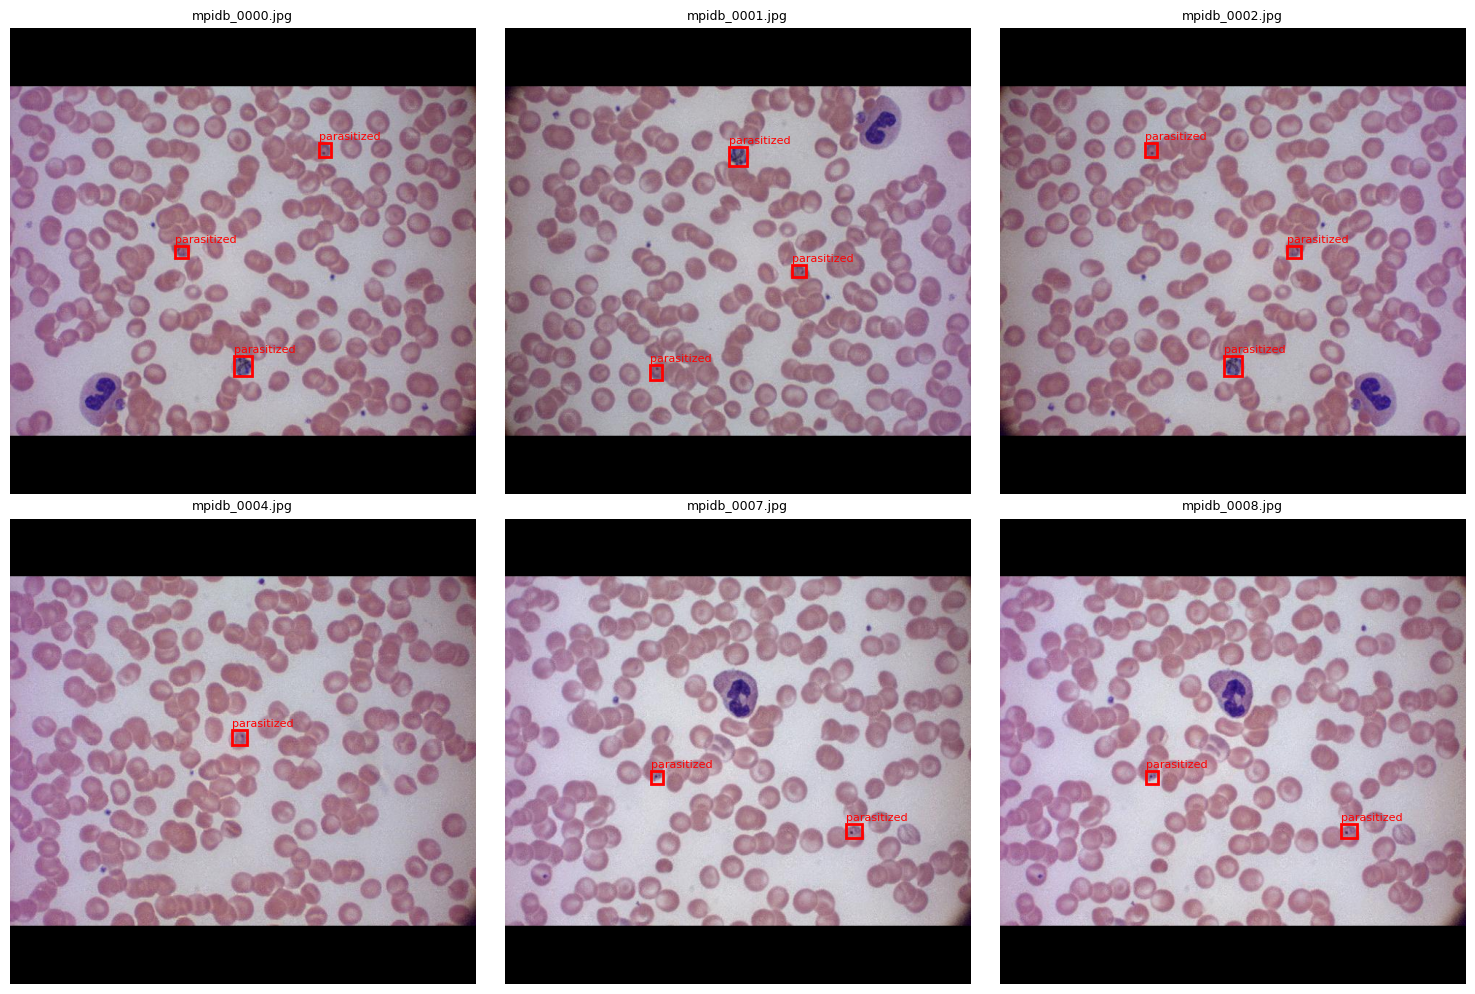

In [18]:
def show_samples(img_dir, lbl_dir, n=6):
    # tampilkan beberapa gambar beserta bounding box ground truth
    class_colors = {0: 'red', 1: 'green'}
    class_names  = {0: 'parasitized', 1: 'uninfected'}

    imgs = list(Path(img_dir).glob('*.jpg'))[:n]
    cols = 3
    rows = (len(imgs) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, img_path in enumerate(imgs):
        img     = cv2.imread(str(img_path))
        h, w    = img.shape[:2]
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[i]
        ax.imshow(img_rgb)

        lbl_path = Path(lbl_dir) / (img_path.stem + '.txt')
        if lbl_path.exists():
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls            = int(parts[0])
                    cx, cy, bw, bh = map(float, parts[1:5])
                    x1 = (cx - bw / 2) * w
                    y1 = (cy - bh / 2) * h
                    rect = patches.Rectangle(
                        (x1, y1), bw * w, bh * h,
                        linewidth=2,
                        edgecolor=class_colors.get(cls, 'blue'),
                        facecolor='none'
                    )
                    ax.add_patch(rect)
                    ax.text(x1, y1 - 4, class_names.get(cls, str(cls)),
                            color=class_colors.get(cls, 'blue'), fontsize=8)

        ax.set_title(img_path.name, fontsize=9)
        ax.axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f"{PATHS['figures']}/sample_train.png", dpi=150, bbox_inches='tight')
    plt.show()


show_samples(PATHS['img_train'], PATHS['lbl_train'])

In [ ]:
def count_classes(lbl_dir):
    counts = {0: 0, 1: 0}
    for lbl_file in Path(lbl_dir).glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    cls = int(parts[0])
                    if cls in counts:
                        counts[cls] += 1
    return counts


# plot distribusi kelas untuk cek apakah data seimbang atau tidak
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
split_names = ['Train', 'Val', 'Test']
lbl_dirs    = [PATHS['lbl_train'], PATHS['lbl_val'], PATHS['lbl_test']]
colors      = ['#e74c3c', '#2ecc71']

for ax, split, lbl_dir in zip(axes, split_names, lbl_dirs):
    counts = count_classes(lbl_dir)
    labels = ['Parasitized', 'Uninfected']
    values = [counts[0], counts[1]]

    bars = ax.bar(labels, values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(split)
    ax.set_ylabel('Number of Objects')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=11)

plt.suptitle('Class Distribution per Split')
plt.tight_layout()
plt.savefig(f"{PATHS['figures']}/class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print('notebook 01 selesai')
print('output:')
print(f'  datasets/processed/images/train : {len(list(Path(PATHS["img_train"]).glob("*.*")))} gambar')
print(f'  datasets/processed/images/val   : {len(list(Path(PATHS["img_val"]).glob("*.*")))} gambar')
print(f'  datasets/processed/images/test  : {len(list(Path(PATHS["img_test"]).glob("*.*")))} gambar')
print(f'  malaria.yaml')

notebook 01 selesai
output:
  datasets/processed/images/train : 21676 gambar
  datasets/processed/images/val   : 5606 gambar
  datasets/processed/images/test  : 2803 gambar
  malaria.yaml


In [21]:
import json

# simpan ringkasan hasil ke file supaya bisa dibaca di notebook lain
summary = {
    'status'        : 'done',
    'PROJECT_ROOT'  : PROJECT_ROOT,
    'total_train'   : len(list(Path(PATHS['img_train']).glob('*.*'))),
    'total_val'     : len(list(Path(PATHS['img_val']).glob('*.*'))),
    'total_test'    : len(list(Path(PATHS['img_test']).glob('*.*'))),
    'yaml_path'     : os.path.join(PROJECT_ROOT, 'malaria.yaml'),
    'PATHS'         : PATHS,
}

summary_path = os.path.join(PROJECT_ROOT, 'notebook01_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('summary disimpan di:', summary_path)
print(json.dumps(summary, indent=2))

summary disimpan di: d:\malaria-detection\notebook01_summary.json
{
  "status": "done",
  "PROJECT_ROOT": "d:\\malaria-detection",
  "total_train": 21676,
  "total_val": 5606,
  "total_test": 2803,
  "yaml_path": "d:\\malaria-detection\\malaria.yaml",
  "PATHS": {
    "raw_nih": "datasets\\raw\\NIH",
    "raw_mpidb": "datasets\\raw\\MP-IDB",
    "processed": "datasets\\processed",
    "img_train": "datasets\\processed\\images\\train",
    "img_val": "datasets\\processed\\images\\val",
    "img_test": "datasets\\processed\\images\\test",
    "lbl_train": "datasets\\processed\\labels\\train",
    "lbl_val": "datasets\\processed\\labels\\val",
    "lbl_test": "datasets\\processed\\labels\\test",
    "figures": "results\\figures"
  }
}
